<center>

# Machine Learning
### Course-End Project # 2 - Creating Cohorts of Songss

</center>

### Project Scenario: 

The customer always looks forward to specialized treatment, whether shopping on an e-commerce website or watching Netflix. The customer desires content that 
aligns with their preferences. To maintain customer engagement, companies must consistently provide the most relevant information. 
 
Starting with Spotify, a Swedish audio streaming and media service provider, boasts over 456 million active monthly users, including more than 195 million paid subscribers as of September 2022. The company aims to create cohorts of different songs to enhance song recommendations. These cohorts will be based on various relevant features, ensuring that each group contains similar types of songs.


### Problem Objective:
As a data scientist, you should perform exploratory data analysis and cluster analysis to create cohorts of songs. The goal is to better understand the various factors that create a cohort of songs.

### Data Description:



### Dataset: 
* The dataset comprises information from Spotify's API regarding all albums by the Rolling Stones available on Spotify. It's crucial to highlight that each song possesses a unique ID.
* project2-rolling-stones-spotify.csv

### Steps to Perform:

1.	Initial data inspection and data cleaning:
    a.	Examine the data initially to identify duplicates, missing values, irrelevant entries, or outliers. Check for any instances of erroneous entries and rectify them as needed

2.	Refine the data for further processing based on your findings

3.	Perform exploratory data analysis and feature engineering

    *	Utilize suitable visualizations to identify the two albums that should be recommended to anyone based on the number of popular songs in each album
    *	Conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns
    *	Examine the relationship between a song's popularity and various factors, exploring how this correlation has evolved
    *	Provide insights on the significance of dimensionality reduction techniques. Share your ideas and elucidate your observations

4.	Perform cluster analysis
    *	Identify the right number of clusters
    *	Use appropriate clustering algorithms
    *	Define each cluster based on the features

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from matplotlib import pyplot as plt

#Import Warnings
import warnings

warnings.filterwarnings("ignore")

In [13]:
# Load the dataset
df = pd.read_csv('project2-rolling-stones-spotify.csv')

In [14]:
# Data dictionary table for the Spotify songs dataset
column_info = pd.DataFrame({
    "Variable": [
        "Unnamed: 0", "name", "album", "release_date", "track_number", "id", "uri",
        "acousticness", "danceability", "energy", "instrumentalness", "liveness",
        "loudness", "speechiness", "tempo", "valence", "popularity", "duration_ms"
    ],
    "Description": [
        "Row index from source file",
        "Name of the song",
        "Album name",
        "Album release date (YYYY-MM-DD)",
        "Track position in the album",
        "Spotify track ID",
        "Spotify URI",
        "Confidence measure (0.0–1.0) of whether the track is acoustic",
        "How suitable a track is for dancing (0.0–1.0)",
        "Perceptual intensity/activity of the track (0.0–1.0)",
        "Likelihood the track contains no vocals (0.0–1.0)",
        "Presence of an audience/live performance feel (0.0–1.0)",
        "Overall track loudness in decibels (dB)",
        "Presence of spoken words in the track (0.0–1.0)",
        "Estimated tempo in beats per minute (BPM)",
        "Musical positiveness/happiness of track (0.0–1.0)",
        "Spotify popularity score (0–100)",
        "Track duration in milliseconds"
    ]
})

column_info

,Variable,Description
0,Unnamed: 0,Row index from source file
1,name,Name of the song
2,album,Album name
3,release_date,Album release date (YYYY-MM-DD)
4,track_number,Track position in the album
5,id,Spotify track ID
6,uri,Spotify URI
7,acousticness,Confidence measure (0.0–1.0) of whether the tr...
8,danceability,How suitable a track is for dancing (0.0–1.0)
9,energy,Perceptual intensity/activity of the track (0....


1) INITIAL INSPECTION
Shape: (1610, 18)

Missing values:
 Unnamed: 0          0
name                0
popularity          0
valence             0
tempo               0
speechiness         0
loudness            0
liveness            0
instrumentalness    0
energy              0
danceability        0
acousticness        0
uri                 0
id                  0
track_number        0
release_date        0
album               0
duration_ms         0
dtype: int64

Duplicate rows: 0

Duplicate track IDs: 0

Cleaned shape: (1610, 18)

Outlier counts (IQR):
instrumentalness    272
speechiness          92
duration_ms          76
popularity           48
tempo                34
loudness             14
energy                8
acousticness          4
danceability          0
liveness              0
valence               0
dtype: int64

Top 2 recommended albums (by # of popular songs):
                                      album  popular_song_count
26  Exile On Main Street (2010 Re-Mastered)     

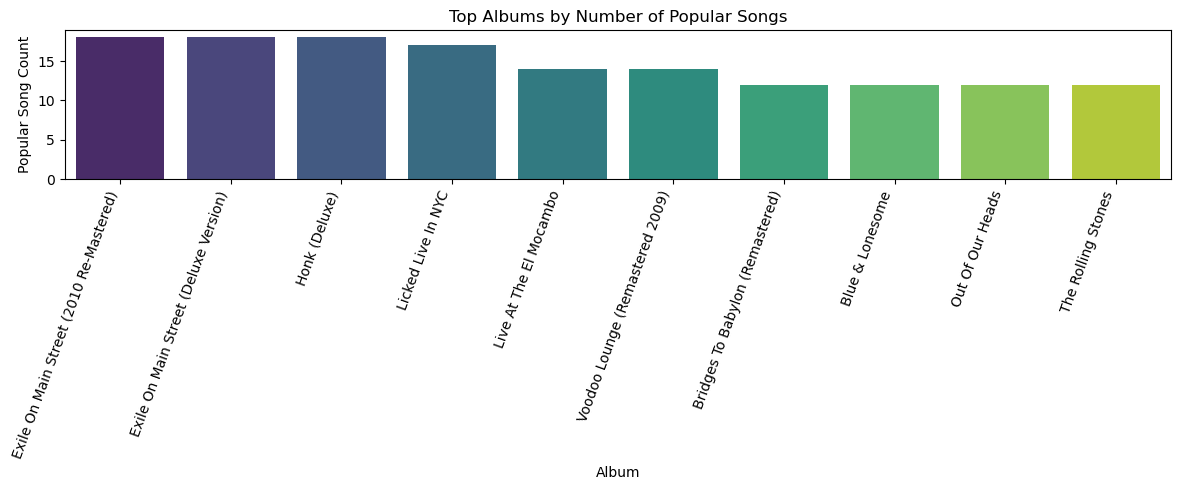

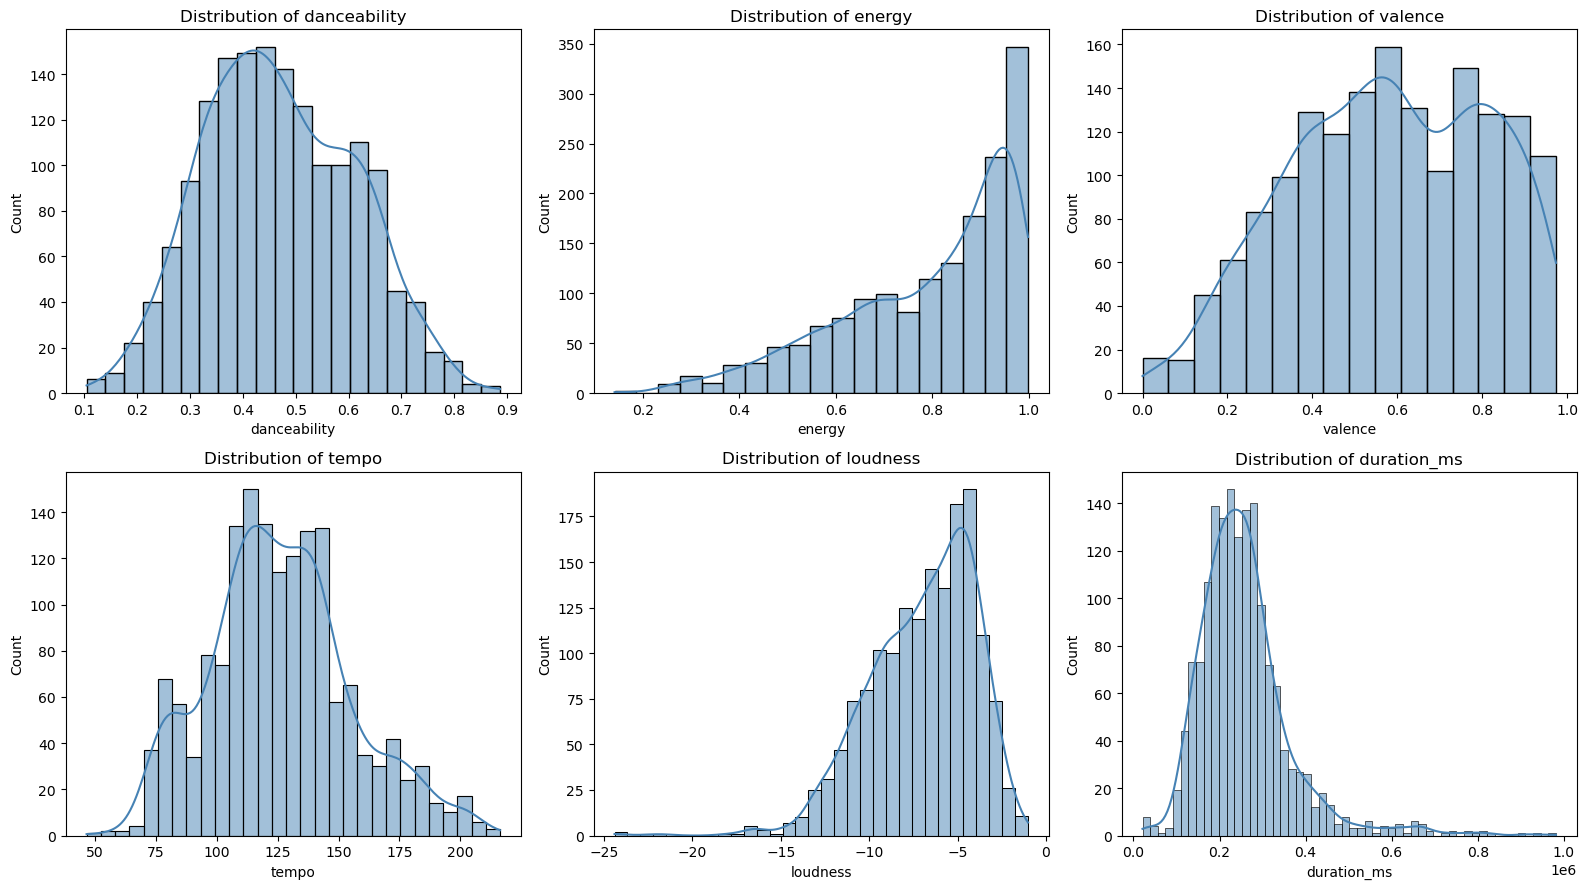

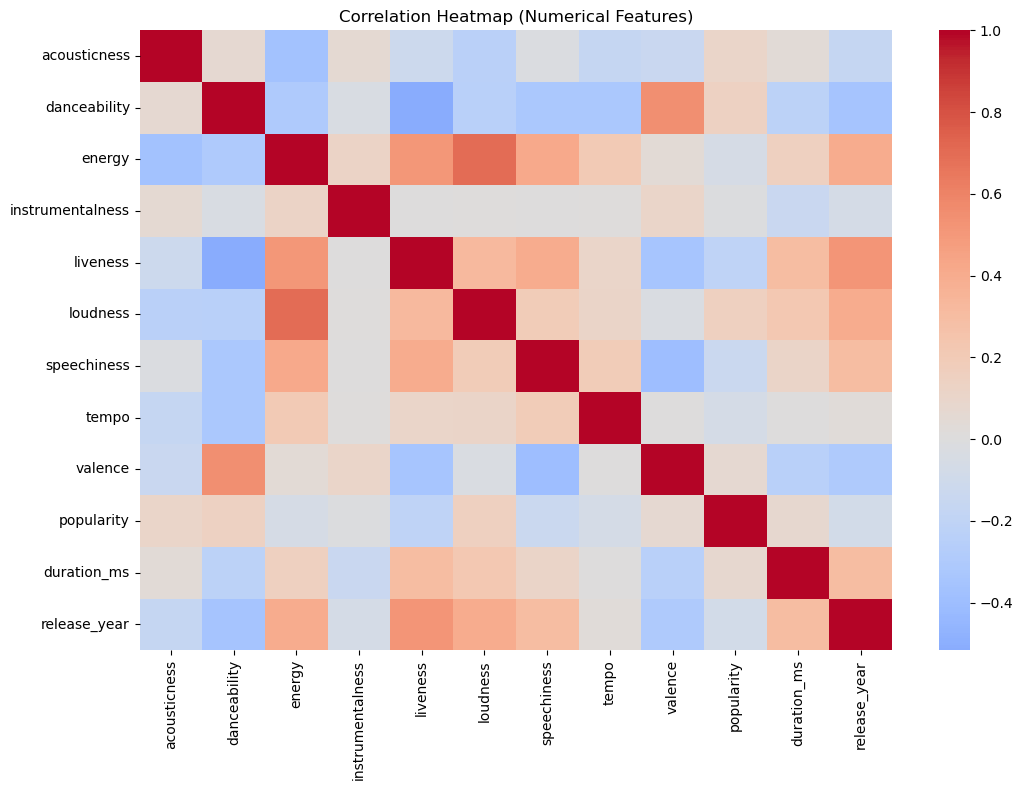


Correlation with popularity:
popularity          1.000000
loudness            0.156323
danceability        0.141205
acousticness        0.108046
duration_ms         0.074102
valence             0.065333
instrumentalness   -0.010612
energy             -0.057272
tempo              -0.061061
release_year       -0.081648
speechiness        -0.136745
liveness           -0.205845
Name: popularity, dtype: float64


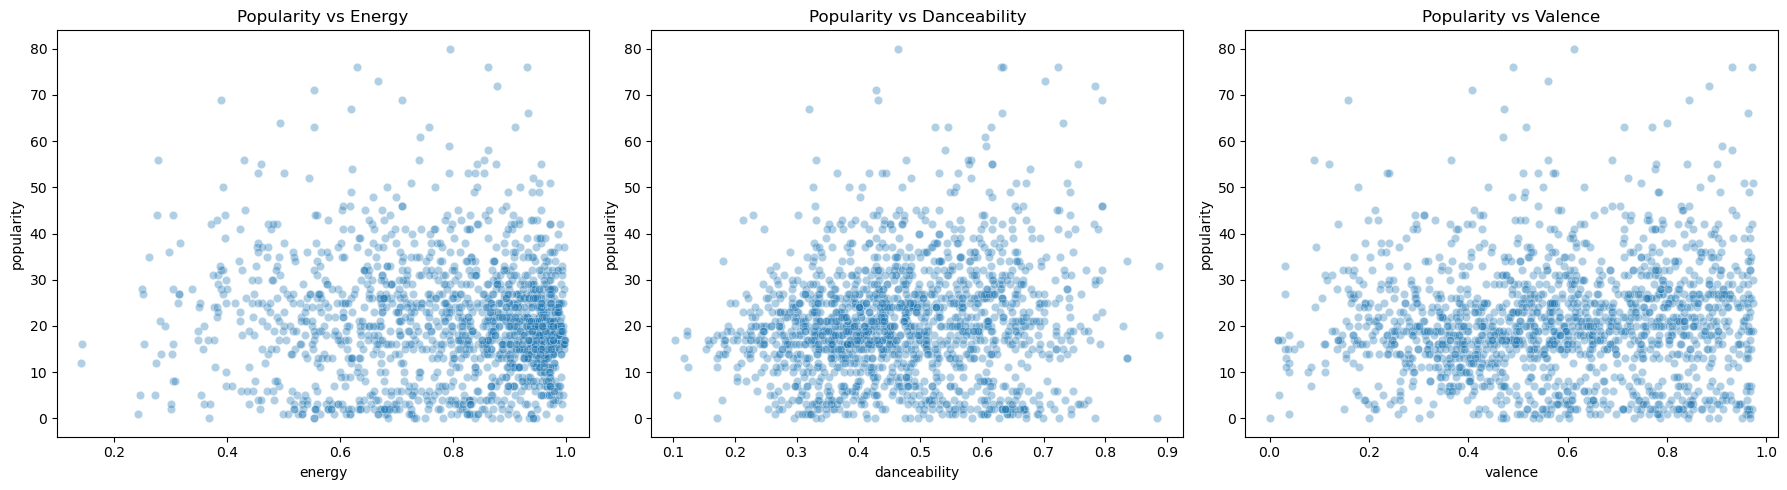

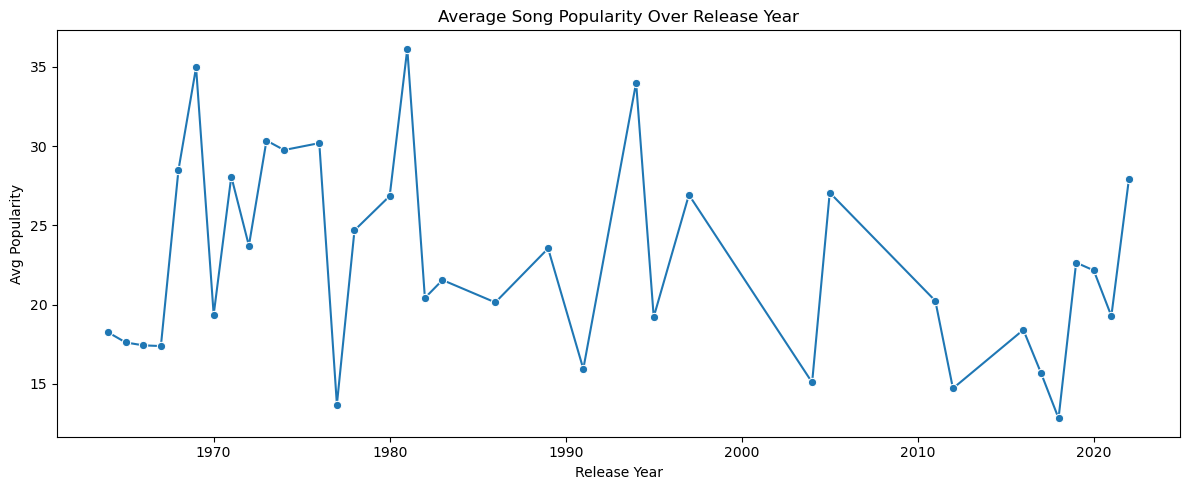


PCA explained variance ratio (PC1, PC2): [0.30326096 0.16514826]
Total explained variance (2 PCs): 0.4684


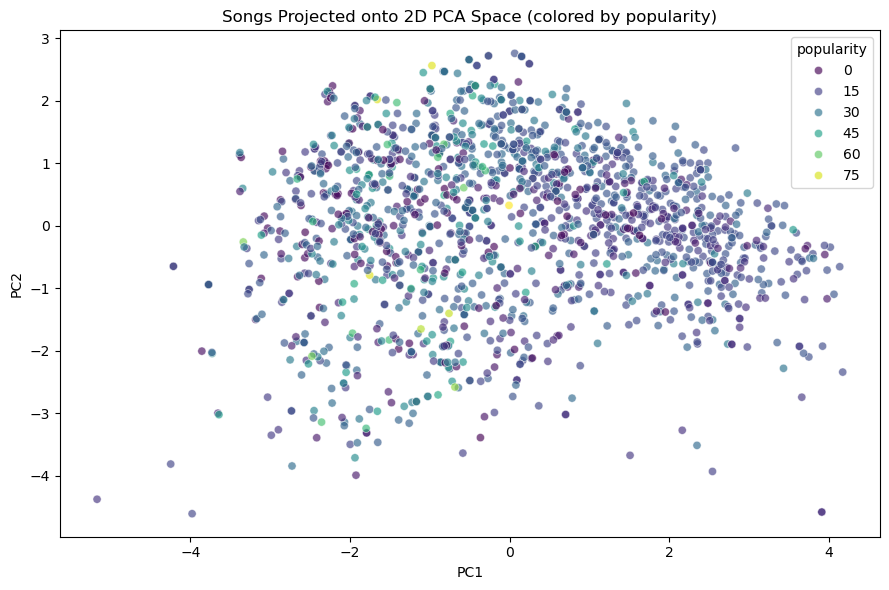


Best K by silhouette score: 2 (score=0.2024)


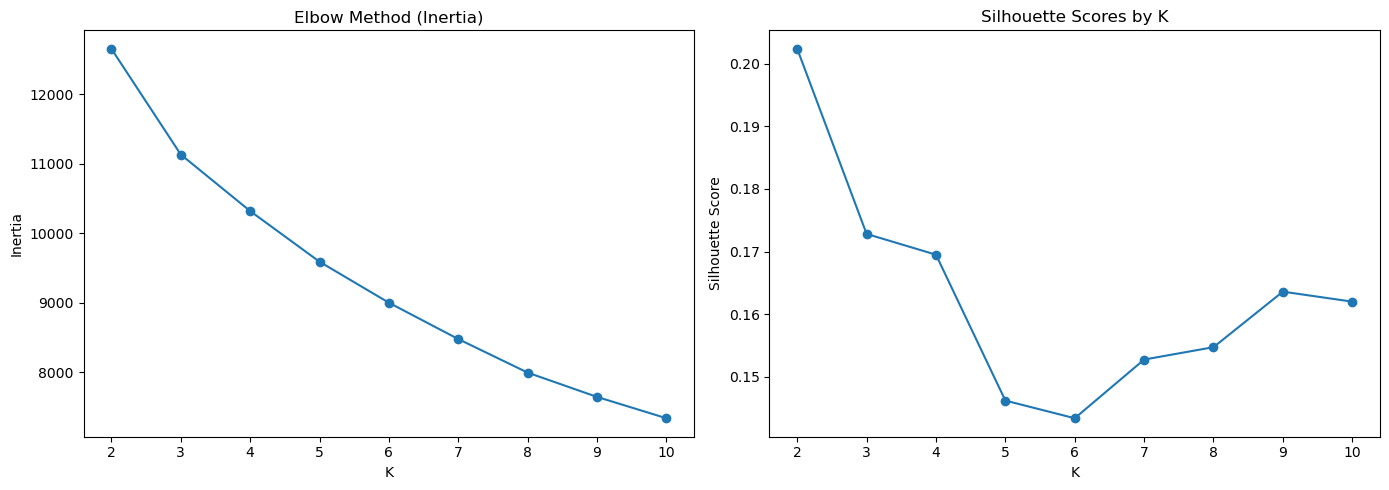

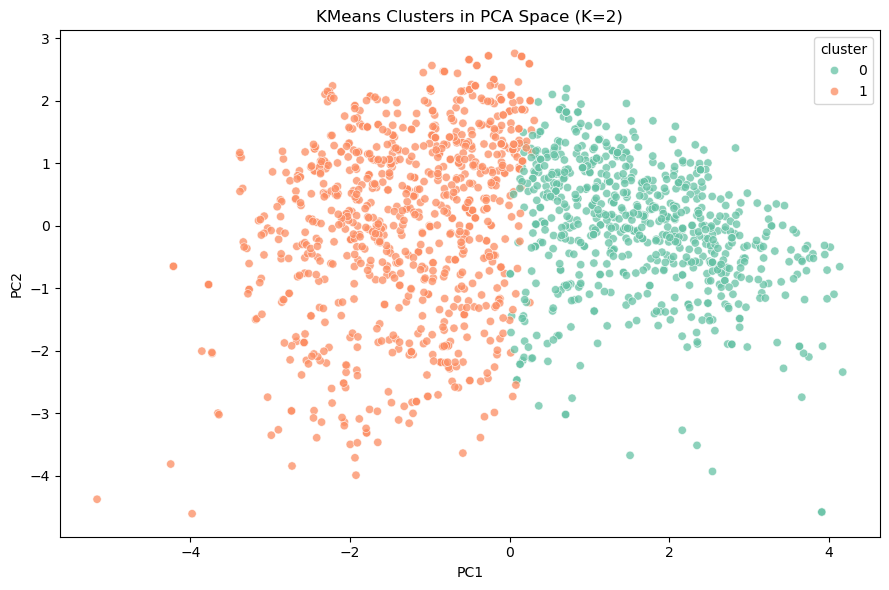


Cluster sizes:
cluster
0    713
1    897
Name: count, dtype: int64

Cluster profile (mean feature values):
         acousticness  danceability  energy  instrumentalness  liveness  \
cluster                                                                   
0               0.195         0.372   0.913             0.160     0.794   
1               0.295         0.546   0.697             0.167     0.252   

         loudness  speechiness    tempo  valence  duration_ms  popularity  
cluster                                                                    
0          -5.458        0.098  134.958    0.479   294479.293      18.339  
1          -8.174        0.047  119.027    0.664   228530.669      22.735  

Interpretation note:
- PCA helps compress many audio features into 2 dimensions for visualization.
- KMeans groups songs with similar audio signatures, enabling song cohort creation.


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =========================
# Project 2 - EDA + Feature Engineering + Clustering (Songs Cohorts)
# =========================


print("=" * 90)
print("1) INITIAL INSPECTION")
print("=" * 90)
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDuplicate track IDs:", df["id"].duplicated().sum())

# -------------------------
# 2) DATA CLEANING / REFINEMENT
# -------------------------
df2 = df.copy()

# Parse dates
df2["release_date"] = pd.to_datetime(df2["release_date"], errors="coerce")
df2["release_year"] = df2["release_date"].dt.year

# Remove exact duplicate tracks by Spotify id (keep first)
df2 = df2.drop_duplicates(subset=["id"]).reset_index(drop=True)

# Drop irrelevant index-like column if present
if "Unnamed: 0" in df2.columns:
    df2 = df2.drop(columns=["Unnamed: 0"])

# Basic outlier check (IQR method, count only)
numeric_cols = [
    "acousticness", "danceability", "energy", "instrumentalness", "liveness",
    "loudness", "speechiness", "tempo", "valence", "popularity", "duration_ms"
]
outlier_counts = {}
for col in numeric_cols:
    q1, q3 = df2[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = ((df2[col] < low) | (df2[col] > high)).sum()

print("\nCleaned shape:", df2.shape)
print("\nOutlier counts (IQR):")
print(pd.Series(outlier_counts).sort_values(ascending=False))

# -------------------------
# 3) EDA + FEATURE ENGINEERING
# -------------------------
# Define "popular songs" as top 25% popularity
pop_threshold = df2["popularity"].quantile(0.75)
df2["is_popular_song"] = (df2["popularity"] >= pop_threshold).astype(int)

# 3a) Two recommended albums by count of popular songs
album_pop = (
    df2.groupby("album", as_index=False)["is_popular_song"]
       .sum()
       .rename(columns={"is_popular_song": "popular_song_count"})
       .sort_values("popular_song_count", ascending=False)
)

top2_albums = album_pop.head(2)
print("\nTop 2 recommended albums (by # of popular songs):")
print(top2_albums)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=album_pop.head(10),
    x="album",
    y="popular_song_count",
    palette="viridis"
)
plt.xticks(rotation=70, ha="right")
plt.title("Top Albums by Number of Popular Songs")
plt.xlabel("Album")
plt.ylabel("Popular Song Count")
plt.tight_layout()
plt.show()

# 3b) Pattern exploration across audio features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
eda_cols = ["danceability", "energy", "valence", "tempo", "loudness", "duration_ms"]
for ax, col in zip(axes.flatten(), eda_cols):
    sns.histplot(df2[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# 3c) Popularity vs factors (correlation + scatter)
corr_cols = numeric_cols + ["release_year"]
corr_matrix = df2[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

pop_corr = corr_matrix["popularity"].sort_values(ascending=False)
print("\nCorrelation with popularity:")
print(pop_corr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df2, x="energy", y="popularity", alpha=0.35, ax=axes[0])
axes[0].set_title("Popularity vs Energy")

sns.scatterplot(data=df2, x="danceability", y="popularity", alpha=0.35, ax=axes[1])
axes[1].set_title("Popularity vs Danceability")

sns.scatterplot(data=df2, x="valence", y="popularity", alpha=0.35, ax=axes[2])
axes[2].set_title("Popularity vs Valence")
plt.tight_layout()
plt.show()

# Popularity evolution over time
yearly_pop = df2.groupby("release_year", as_index=False)["popularity"].mean()
plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_pop, x="release_year", y="popularity", marker="o")
plt.title("Average Song Popularity Over Release Year")
plt.xlabel("Release Year")
plt.ylabel("Avg Popularity")
plt.tight_layout()
plt.show()

# 3d) Dimensionality reduction insight (PCA)
cluster_features = [
    "acousticness", "danceability", "energy", "instrumentalness", "liveness",
    "loudness", "speechiness", "tempo", "valence", "duration_ms"
]
X = df2[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df2["PC1"] = X_pca[:, 0]
df2["PC2"] = X_pca[:, 1]

print("\nPCA explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)
print("Total explained variance (2 PCs):", pca.explained_variance_ratio_.sum().round(4))

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=df2["PC1"], y=df2["PC2"],
    hue=df2["popularity"], palette="viridis", alpha=0.65, s=35
)
plt.title("Songs Projected onto 2D PCA Space (colored by popularity)")
plt.tight_layout()
plt.show()

# -------------------------
# 4) CLUSTER ANALYSIS
# -------------------------
inertia = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = k_values[int(np.argmax(sil_scores))]
print(f"\nBest K by silhouette score: {best_k} (score={max(sil_scores):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_values), inertia, marker="o")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_values), sil_scores, marker="o")
axes[1].set_title("Silhouette Scores by K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df2["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df2, x="PC1", y="PC2",
    hue="cluster", palette="Set2", alpha=0.75
)
plt.title(f"KMeans Clusters in PCA Space (K={best_k})")
plt.tight_layout()
plt.show()

cluster_profile = (
    df2.groupby("cluster")[cluster_features + ["popularity"]]
       .mean()
       .round(3)
)
cluster_sizes = df2["cluster"].value_counts().sort_index()

print("\nCluster sizes:")
print(cluster_sizes)
print("\nCluster profile (mean feature values):")
print(cluster_profile)

print("\nInterpretation note:")
print("- PCA helps compress many audio features into 2 dimensions for visualization.")
print("- KMeans groups songs with similar audio signatures, enabling song cohort creation.")